# 1. Carga de datos

## 1.1. Lectura datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

In [2]:
# Ruta al archivo
file_path = "../../data/experiment_0.json"

df = pd.read_json(file_path)

print("="*70)
print("Primeras 5 filas:\n")
print(df.head(5).to_string(index=False))
print("="*70)

Primeras 5 filas:

 header_stamp  seq_id  t_rx                                          topic  valid  original_stamp          aux                      source_topic
        2.836     119 2.836 /robot/robotnik_base_control/odom_instrumented  False           2.809 4.684623e-07 /robot/robotnik_base_control/odom
        2.836     120 2.836 /robot/robotnik_base_control/odom_instrumented  False           2.831 4.853336e-07 /robot/robotnik_base_control/odom
        2.870     121 2.870 /robot/robotnik_base_control/odom_instrumented  False           2.852 4.684631e-07 /robot/robotnik_base_control/odom
        2.874     122 2.875 /robot/robotnik_base_control/odom_instrumented  False           2.873 4.853344e-07 /robot/robotnik_base_control/odom
        2.911     123 2.912 /robot/robotnik_base_control/odom_instrumented  False           2.893 4.684639e-07 /robot/robotnik_base_control/odom


## 1.2. Analisis de calidad

In [3]:
report = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "nulls": df.isna().sum().values,
    "null_%": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique().values
})

print("\n" + "="*70)
print("DATA QUALITY REPORT")
print("="*70)
print(report.to_string(index=False))
print("="*70)

print(f"\nTotal filas: {len(df)}")
print(f"Total columnas: {df.shape[1]}")
print(f"Total nulos: {df.isna().sum().sum()}")


DATA QUALITY REPORT
        column   dtype  nulls  null_%  unique_values
  header_stamp float64      0     0.0          48936
        seq_id   int64      0     0.0          54525
          t_rx float64      0     0.0          47064
         topic     str      0     0.0              5
         valid    bool      0     0.0              2
original_stamp float64      0     0.0          55469
           aux float64      0     0.0          20008
  source_topic     str      0     0.0              5

Total filas: 75987
Total columnas: 8
Total nulos: 0


# 2. Normalizacion

## 2.1. Unificar timestamps

In [4]:
df["t_rx"] = df["t_rx"].astype(float)
df["original_stamp"] = df["original_stamp"].astype(float)

In [5]:
df = df.sort_values("t_rx").reset_index(drop=True)

# 3. Segmentación por goal

## 3.1 Crear ventanas temporales

In [6]:
segments = []

goal_times = df[df["source_topic"] == "/robot/move_base_simple/goal"]["t_rx"].values

for i in range(len(goal_times)):
    t_start = goal_times[i]
    t_end = goal_times[i+1] if i < len(goal_times)-1 else df["t_rx"].max()

    segment = df[(df["t_rx"] >= t_start) & (df["t_rx"] < t_end)].copy()
    segment["goal_id"] = i

    segments.append(segment)

df_segmented = pd.concat(segments).reset_index(drop=True)

In [7]:
print("="*70)
print("Primeras 5 filas:\n")
print(df_segmented.head(5).to_string(index=False))
print("="*70)

Primeras 5 filas:

 header_stamp  seq_id   t_rx                                          topic  valid  original_stamp      aux                      source_topic  goal_id
       19.526       1 19.526      /robot/move_base_simple/goal_instrumented   True           0.000 0.000000      /robot/move_base_simple/goal        0
       19.530     914 19.530 /robot/robotnik_base_control/odom_instrumented   True          19.505 0.338791 /robot/robotnik_base_control/odom        0
       19.530     915 19.530 /robot/robotnik_base_control/odom_instrumented   True          19.526 0.338791 /robot/robotnik_base_control/odom        0
       19.570     916 19.570 /robot/robotnik_base_control/odom_instrumented   True          19.547 0.338791 /robot/robotnik_base_control/odom        0
       19.570     917 19.570 /robot/robotnik_base_control/odom_instrumented   True          19.568 0.338802 /robot/robotnik_base_control/odom        0


## 3.2 Verificación

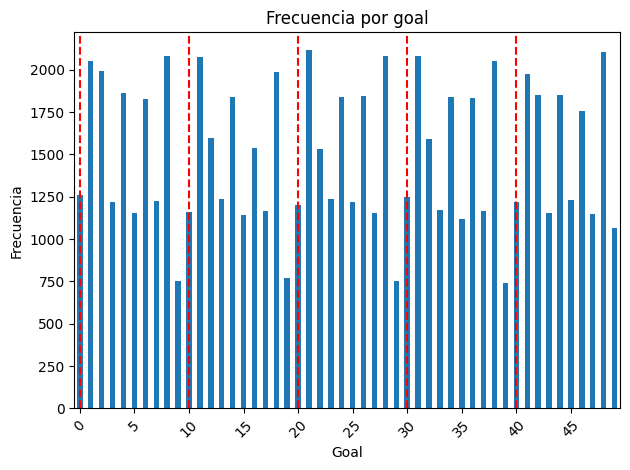

In [8]:

counts = df_segmented["goal_id"].value_counts().sort_index()

plt.figure()
counts.plot(kind="bar")

# Añadir líneas verticales cada 10 valores
for i, goal in enumerate(counts.index):
    if goal % 10 == 0:
        plt.axvline(x=i, color="red", linestyle="--", )



plt.title("Frecuencia por goal")
plt.xlabel("Goal")
plt.ylabel("Frecuencia")
step = 5  # muestra 1 de cada 5 etiquetas (ajusta según densidad)
plt.xticks(
    ticks=range(0, len(counts), step),
    labels=counts.index[::step],
    rotation=45
)
plt.tight_layout()

plt.show()

# 4. Detección de eventos

## 4.1. Nearest + DTW matching

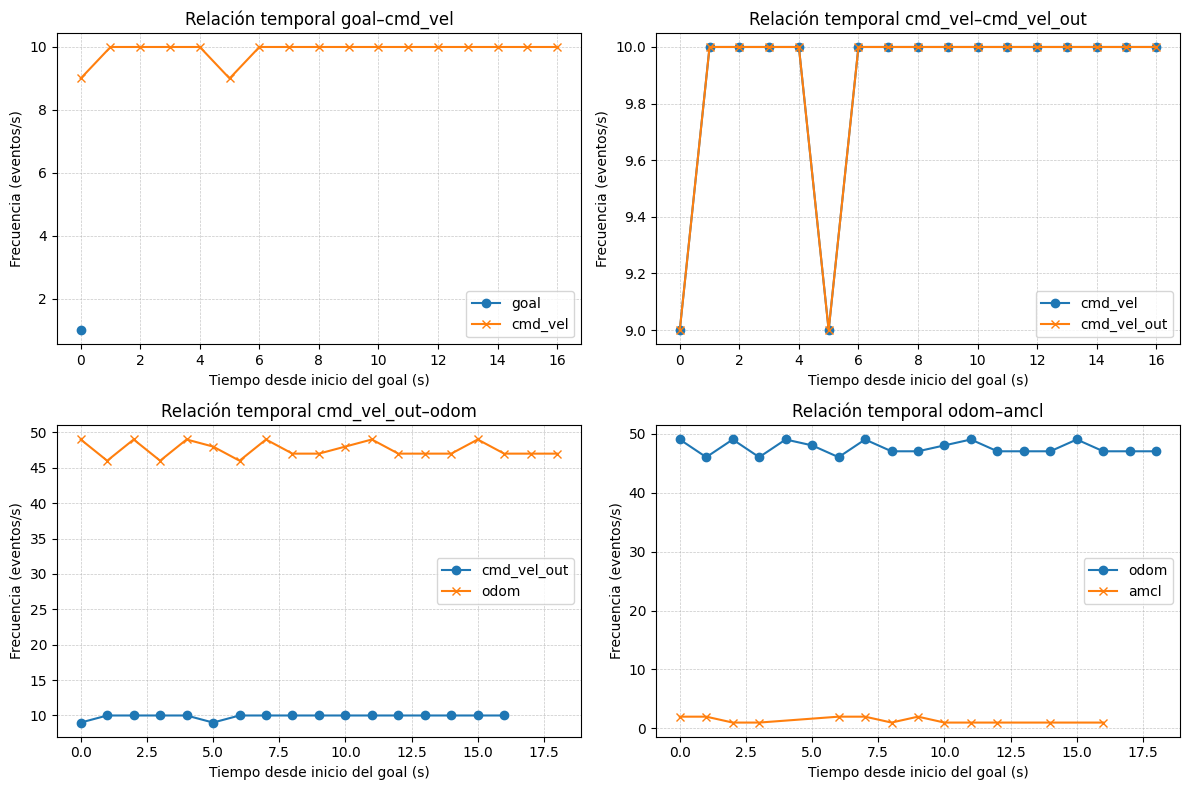

In [9]:

# --- Selección de goal ---
gid = 0
segment = df_segmented[df_segmented["goal_id"] == gid]

# --- Tiempo de referencia (goal) ---
t0 = segment.loc[
    segment["topic"] == "/robot/move_base_simple/goal_instrumented",
    "t_rx"
].iloc[0]

# --- Mapeo de nombres coherente ---
label_map = {
    "/robot/move_base_simple/goal_instrumented": "goal",
    "/robot/move_base/cmd_vel_instrumented": "cmd_vel",
    "/robot/robotnik_base_control/cmd_vel_instrumented": "cmd_vel_out",
    "/robot/robotnik_base_control/odom_instrumented": "odom",
    "/robot/amcl_pose_instrumented": "amcl",
}

# --- Función de frecuencia por segundo ---
def compute_frequency(segment, topic, t0):
    df = segment[segment["topic"] == topic].copy()
    
    if df.empty:
        return None
    
    df["t_rel"] = df["t_rx"] - t0
    df["sec"] = np.floor(df["t_rel"]).astype(int)
    
    return df.groupby("sec").size()

# --- Definición de pares y títulos coherentes ---
pairs = [
    ("/robot/move_base_simple/goal_instrumented",
     "/robot/move_base/cmd_vel_instrumented",
     "Relación temporal goal–cmd_vel"),

    ("/robot/move_base/cmd_vel_instrumented",
     "/robot/robotnik_base_control/cmd_vel_instrumented",
     "Relación temporal cmd_vel–cmd_vel_out"),

    ("/robot/robotnik_base_control/cmd_vel_instrumented",
     "/robot/robotnik_base_control/odom_instrumented",
     "Relación temporal cmd_vel_out–odom"),

    ("/robot/robotnik_base_control/odom_instrumented",
     "/robot/amcl_pose_instrumented",
     "Relación temporal odom–amcl"),
]

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (t1, t2, title) in zip(axes, pairs):

    f1 = compute_frequency(segment, t1, t0)
    f2 = compute_frequency(segment, t2, t0)

    if f1 is not None:
        ax.plot(f1.index, f1.values, marker='o',
                label=label_map[t1])

    if f2 is not None:
        ax.plot(f2.index, f2.values, marker='x',
                label=label_map[t2])

    ax.set_title(title)
    ax.set_xlabel("Tiempo desde inicio del goal (s)")
    ax.set_ylabel("Frecuencia (eventos/s)")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.legend()

plt.tight_layout()

# --- Guardado con transparencia ---
plt.savefig("../../docs/figures/asynchronous_event_frequencies.png",
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

In [10]:
events = []
total_goals = 0
discarded_goals = 0

for gid, segment in df_segmented.groupby("goal_id"):
    total_goals += 1

    # --- GOAL ---
    goal = segment[segment["topic"] == "/robot/move_base_simple/goal_instrumented"]
    if goal.empty:
        discarded_goals += 1
        continue
    t_goal = goal["t_rx"].iloc[0]

    # --- CMD ---
    cmd = segment[
        (segment["topic"] == "/robot/move_base/cmd_vel_instrumented") &
        (segment["t_rx"] > t_goal)
    ]
    if cmd.empty:
        discarded_goals += 1
        continue
    t_cmd = cmd["t_rx"].iloc[0]

    # --- CMD_OUT ---
    cmd_out = segment[
        (segment["topic"] == "/robot/robotnik_base_control/cmd_vel_instrumented") &
        (segment["t_rx"] > t_cmd)
    ]
    if cmd_out.empty:
        discarded_goals += 1
        continue
    t_cmd_out = cmd_out["t_rx"].iloc[0]

    # =========================
    # DTW: CMD_OUT → ODOM
    # =========================
    cmd_out_times = np.sort(
        segment[
            (segment["topic"] == "/robot/robotnik_base_control/cmd_vel_instrumented") &
            (segment["t_rx"] > t_cmd)
        ]["t_rx"].values
    )

    odom_times = np.sort(
        segment[
            (segment["topic"] == "/robot/robotnik_base_control/odom_instrumented") &
            (segment["t_rx"] > t_cmd_out)
        ]["t_rx"].values
    )

    if len(cmd_out_times) == 0 or len(odom_times) == 0:
        discarded_goals += 1
        continue

    _, path = fastdtw(
        cmd_out_times.reshape(-1,1),
        odom_times.reshape(-1,1),
        dist=euclidean
    )

    idx_cmd_out = np.argmin(np.abs(cmd_out_times - t_cmd_out))

    t_odom = None
    for i, j in path:
        if i == idx_cmd_out:
            t_odom = odom_times[j]
            break

    if t_odom is None or t_odom <= t_cmd_out:
        discarded_goals += 1
        continue

    # =========================
    # DTW: ODOM → AMCL
    # =========================
    odom_times = np.sort(
        segment[
            (segment["topic"] == "/robot/robotnik_base_control/odom_instrumented") &
            (segment["t_rx"] > t_cmd_out)
        ]["t_rx"].values
    )

    amcl_times = np.sort(
        segment[
            (segment["topic"] == "/robot/amcl_pose_instrumented") &
            (segment["t_rx"] > t_odom)
        ]["t_rx"].values
    )

    if len(amcl_times) == 0:
        discarded_goals += 1
        continue

    _, path = fastdtw(
        odom_times.reshape(-1,1),
        amcl_times.reshape(-1,1),
        dist=euclidean
    )

    idx_odom = np.argmin(np.abs(odom_times - t_odom))

    t_amcl = None
    for i, j in path:
        if i == idx_odom:
            t_amcl = amcl_times[j]
            break

    if t_amcl is None or t_amcl <= t_odom:
        discarded_goals += 1
        continue

    # --- SAVE ---
    events.append({
        "goal_id": gid,
        "t_goal": t_goal,
        "t_cmd": t_cmd,
        "t_cmd_out": t_cmd_out,
        "t_odom": t_odom,
        "t_amcl": t_amcl
    })

df_events = pd.DataFrame(events)

print("="*70)
print(f"Total goals: {total_goals}")
print(f"Descartados: {discarded_goals}")
print(f"% descartados: {discarded_goals / total_goals * 100:.2f}%")
print("="*70)

Total goals: 50
Descartados: 0
% descartados: 0.00%


In [11]:
invalid_order = df_events[
    ~(
        (df_events["t_goal"] <= df_events["t_cmd"]) &
        (df_events["t_cmd"] <= df_events["t_cmd_out"]) &
        (df_events["t_cmd_out"] <= df_events["t_odom"]) &
        (df_events["t_odom"] <= df_events["t_amcl"])
    )
]
print("="*70)
print(f"Eventos con orden temporal inválido: {len(invalid_order)}")
print("-"*70)
print(f"Filas totales: {len(df_events)}")
print(f"Columnas: {df_events.shape[1]}")
print("-"*70)
print("Primeras 5 filas:\n")
print(df_events.head(5).to_string(index=False))
print("-"*70)
print("="*70)

Eventos con orden temporal inválido: 0
----------------------------------------------------------------------
Filas totales: 50
Columnas: 6
----------------------------------------------------------------------
Primeras 5 filas:

 goal_id  t_goal   t_cmd  t_cmd_out  t_odom  t_amcl
       0  19.526  19.690     19.787  19.791  19.977
       1  38.480  38.652     38.657  38.658  40.362
       2  69.168  69.344     69.439  69.480  69.844
       3  99.054  99.201     99.297  99.339  99.876
       4 117.478 117.633    117.733 117.741 118.439
----------------------------------------------------------------------


## 4.2. Normalización de timestamps

In [12]:
time_cols = ["t_cmd", "t_cmd_out", "t_odom", "t_amcl", "t_goal"]

t0 = df_events["t_goal"].copy()

for col in time_cols:
    df_events[col] = df_events[col] - t0

In [13]:
print("="*70)
print(f"Filas totales: {len(df_events)}")
print(f"Columnas: {df_events.shape[1]}")
print("-"*70)
print("Primeras 5 filas:\n")
print(df_events.head(5).to_string(index=False))
print("-"*70)
print("="*70)

Filas totales: 50
Columnas: 6
----------------------------------------------------------------------
Primeras 5 filas:

 goal_id  t_goal  t_cmd  t_cmd_out  t_odom  t_amcl
       0     0.0  0.164      0.261   0.265   0.451
       1     0.0  0.172      0.177   0.178   1.882
       2     0.0  0.176      0.271   0.312   0.676
       3     0.0  0.147      0.243   0.285   0.822
       4     0.0  0.155      0.255   0.263   0.961
----------------------------------------------------------------------


# 5. Calculo de latencias

## 5.1 Definir métricas

In [14]:
df_events["L_plan_control"] = df_events["t_cmd"] - df_events["t_goal"]
df_events["L_mux"]          = df_events["t_cmd_out"] - df_events["t_cmd"]
df_events["L_exec"]         = df_events["t_odom"] - df_events["t_cmd_out"]
df_events["L_local"]        = df_events["t_amcl"] - df_events["t_odom"]

df_events["L_e2e_odom"]          = df_events["t_odom"] - df_events["t_goal"]

df_events["L_e2e_amcl"]     = df_events["t_amcl"] - df_events["t_goal"]

In [15]:
latency_cols = ["L_plan_control", "L_mux", "L_exec", "L_local", "L_e2e_odom", "L_e2e_amcl"]

print("="*70)
print(f"Filas totales: {len(df_events)}")
print(f"Columnas: {df_events.shape[1]}")
print("-"*70)
print("Primeras 5 filas:\n")
print(df_events[latency_cols].head(5).to_string(index=False))
print("-"*70)
print("="*70)

Filas totales: 50
Columnas: 12
----------------------------------------------------------------------
Primeras 5 filas:

 L_plan_control  L_mux  L_exec  L_local  L_e2e_odom  L_e2e_amcl
          0.164  0.097   0.004    0.186       0.265       0.451
          0.172  0.005   0.001    1.704       0.178       1.882
          0.176  0.095   0.041    0.364       0.312       0.676
          0.147  0.096   0.042    0.537       0.285       0.822
          0.155  0.100   0.008    0.698       0.263       0.961
----------------------------------------------------------------------


# 6. Validación y limpieza

In [16]:
# Comprobacion de que no hay overlap o intervalos mal definidos
lat_sum = (
    df_events["L_plan_control"] +
    df_events["L_mux"] +
    df_events["L_exec"] +
    df_events["L_local"]
)

error = lat_sum - df_events["L_e2e_amcl"]

print("="*70)
print("Error absoluto medio:", error.abs().mean())
print("Error máximo:", error.abs().max())

tolerance = 1e-6 

inconsistent = df_events[error.abs() > tolerance]

print(f"Eventos inconsistentes: {len(inconsistent)}")
print("="*70)

Error absoluto medio: 0.0
Error máximo: 0.0
Eventos inconsistentes: 0


In [17]:
# Todas las latencias deben ser >= 0
cols = ["L_plan_control","L_mux","L_exec","L_local","L_e2e_odom","L_e2e_amcl"]
print("="*70)
print((df_events[cols] >= 0).all())
print("="*70)


L_plan_control    True
L_mux             True
L_exec            True
L_local           True
L_e2e_odom        True
L_e2e_amcl        True
dtype: bool


# 7. Análisis estadístico

## 7.1 Métricas básicas

In [18]:
cols = ["L_plan_control","L_mux","L_exec","L_local","L_e2e_odom","L_e2e_amcl"]

stats = df_events[cols].agg(["mean","std","min","max","median"])
print("="*70)
print(stats)
print("="*70)


        L_plan_control     L_mux    L_exec   L_local  L_e2e_odom  L_e2e_amcl
mean          0.160160  0.069280  0.020040  0.468420    0.249480    0.717900
std           0.014345  0.044558  0.012691  0.350244    0.053093    0.345731
min           0.132000  0.001000  0.001000  0.004000    0.155000    0.279000
max           0.194000  0.107000  0.042000  1.704000    0.328000    1.882000
median        0.160500  0.099000  0.020000  0.418000    0.267000    0.657000


## 7.2 Percentiles

In [19]:
percentiles = df_events[cols].quantile([0.5, 0.9, 0.95, 0.99])
print("="*70)
print(percentiles)
print("="*70)


      L_plan_control    L_mux   L_exec  L_local  L_e2e_odom  L_e2e_amcl
0.50         0.16050  0.09900  0.02000  0.41800     0.26700     0.65700
0.90         0.17840  0.10110  0.03620  0.74990     0.30410     1.01510
0.95         0.18520  0.10310  0.04010  1.29510     0.31310     1.53155
0.99         0.19253  0.10553  0.04151  1.52809     0.32212     1.74872


## 7.3 Variabilidad relativa

In [20]:
cv = df_events[cols].std() / df_events[cols].mean()
print("="*70)
print(cv)
print("="*70)


L_plan_control    0.089565
L_mux             0.643154
L_exec            0.633280
L_local           0.747714
L_e2e_odom        0.212813
L_e2e_amcl        0.481587
dtype: float64


## 7.4 Contribución por etapa

In [21]:
contrib = df_events[["L_plan_control","L_mux","L_exec","L_local"]].mean()
contrib_amcl = contrib / df_events["L_e2e_amcl"].mean()
print("="*70)
print(contrib_amcl)
print("="*70)


L_plan_control    0.223095
L_mux             0.096504
L_exec            0.027915
L_local           0.652486
dtype: float64


## 7.5 Detección de outliers por percentil (P99)

In [22]:
cols = ["L_plan_control","L_mux","L_exec","L_local","L_e2e_odom","L_e2e_amcl"]

results = {}

for col in cols:
    p99 = df_events[col].quantile(0.99)
    
    outliers = df_events[df_events[col] > p99]
    
    results[col] = {
        "p99": p99,
        "n_outliers": len(outliers),
        "perc_outliers": len(outliers) / len(df_events) * 100
    }

# Mostrar resultados
print("="*70)
for col, res in results.items():
    print(f"\n--- {col} ---")
    print(f"P99: {res['p99']:.4f}")
    print(f"Nº outliers: {res['n_outliers']}")
    print(f"% outliers: {res['perc_outliers']:.2f}%")
print("="*70)



--- L_plan_control ---
P99: 0.1925
Nº outliers: 1
% outliers: 2.00%

--- L_mux ---
P99: 0.1055
Nº outliers: 1
% outliers: 2.00%

--- L_exec ---
P99: 0.0415
Nº outliers: 1
% outliers: 2.00%

--- L_local ---
P99: 1.5281
Nº outliers: 1
% outliers: 2.00%

--- L_e2e_odom ---
P99: 0.3221
Nº outliers: 1
% outliers: 2.00%

--- L_e2e_amcl ---
P99: 1.7487
Nº outliers: 1
% outliers: 2.00%


# 8. Visualización

## 8.1 Histogramas

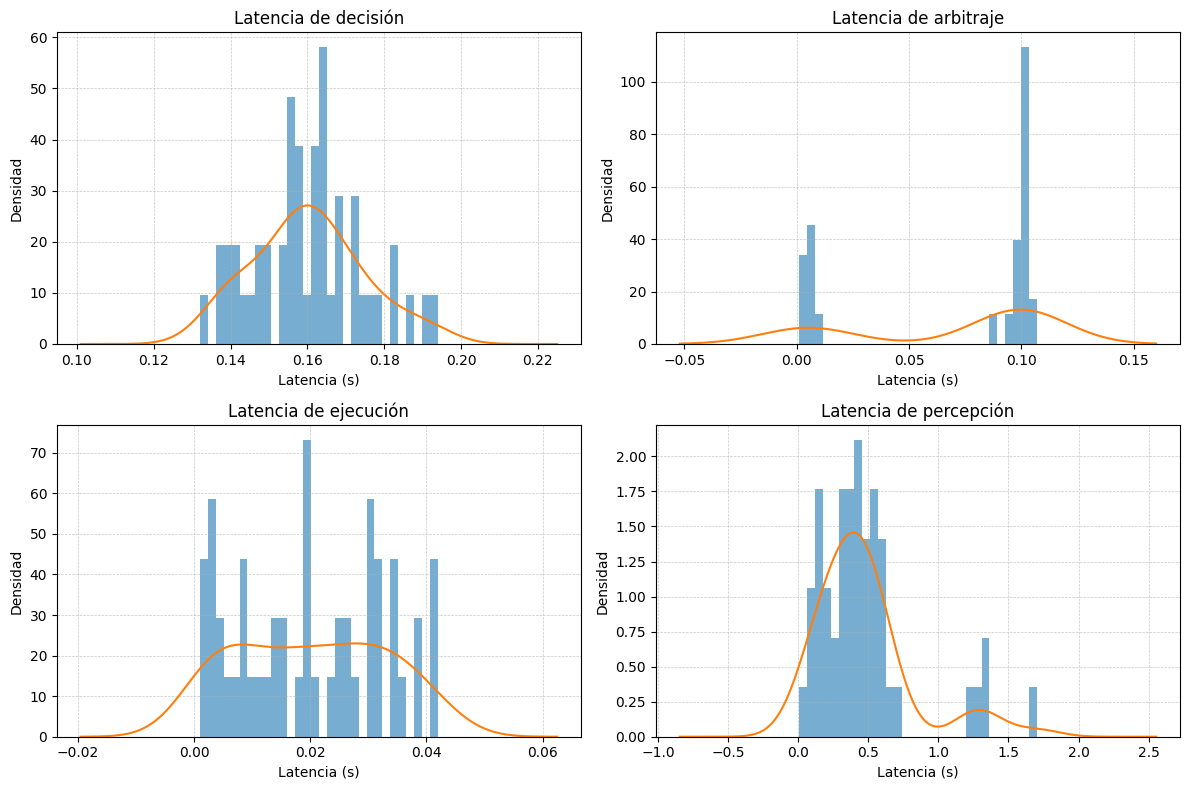

In [23]:
cols = ["L_plan_control","L_mux","L_exec","L_local"]

labels = {
    "L_plan_control": "Latencia de decisión",
    "L_mux": "Latencia de arbitraje",
    "L_exec": "Latencia de ejecución",
    "L_local": "Latencia de percepción"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    
    # Histograma
    df_events[col].plot(kind="hist", bins=30, density=True, ax=ax, alpha=0.6)
    
    # KDE
    df_events[col].plot(kind="kde", ax=ax)
    
    ax.set_title(labels[col])
    ax.set_xlabel("Latencia (s)")
    ax.set_ylabel("Densidad")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


plt.tight_layout()

# --- Guardado con transparencia ---
plt.savefig("../../docs/figures/subsystem_latency_density_distribution.png",
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

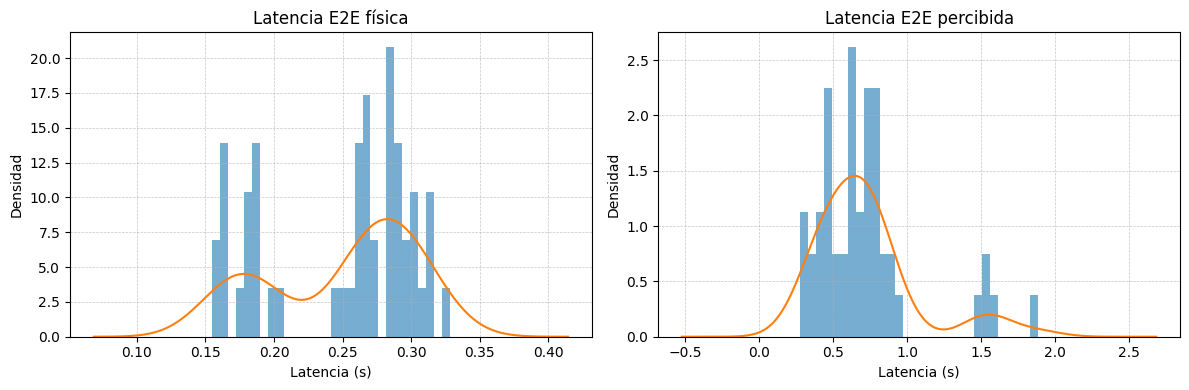

In [24]:
cols = ["L_e2e_odom","L_e2e_amcl"]

labels = {
    "L_e2e_odom": "Latencia E2E física",
    "L_e2e_amcl": "Latencia E2E percibida"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    
    # Histograma
    df_events[col].plot(kind="hist", bins=30, density=True, ax=ax, alpha=0.6)
    
    # KDE
    df_events[col].plot(kind="kde", ax=ax)
    
    ax.set_title(labels[col])
    ax.set_xlabel("Latencia (s)")
    ax.set_ylabel("Densidad")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


plt.tight_layout()

# --- Guardado con transparencia ---
plt.savefig("../../docs/figures/e2e_latency_density_distribution.png",
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

plt.show()

## 8.2. Boxplot

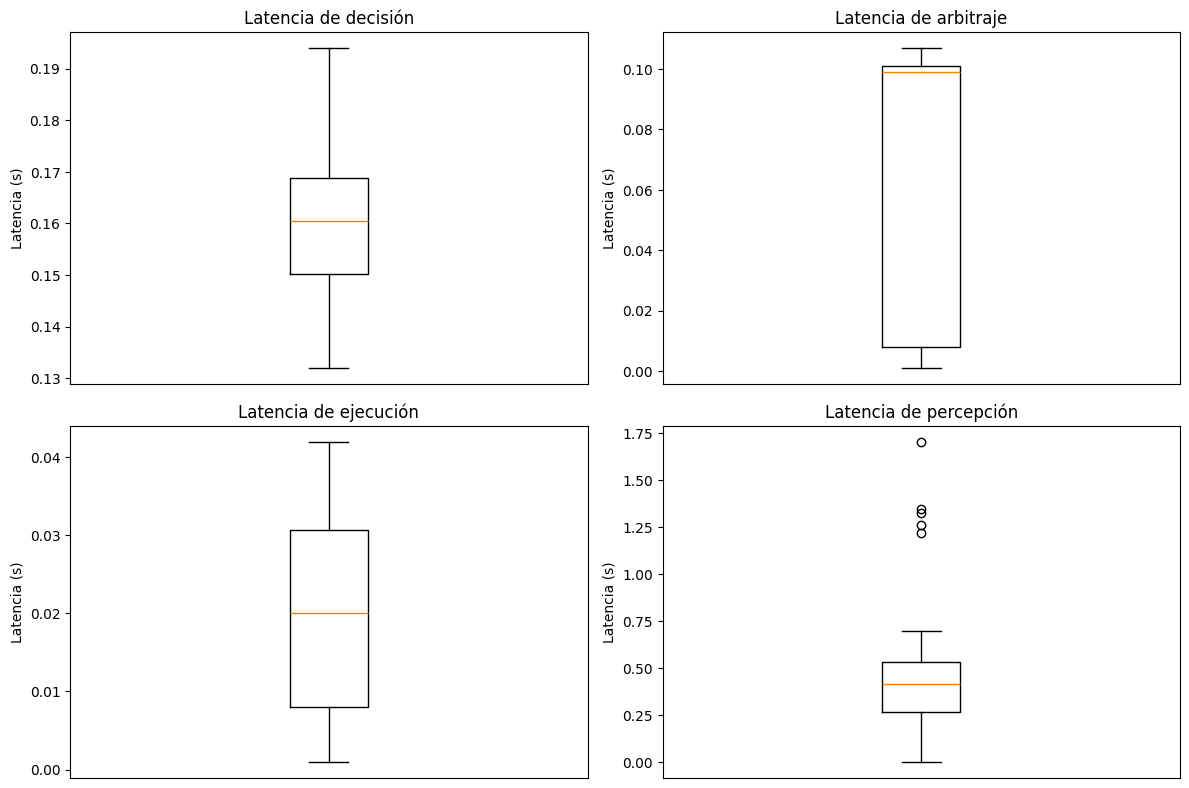

In [25]:

cols = ["L_plan_control","L_mux","L_exec","L_local"]

labels = {
    "L_plan_control": "Latencia de decisión",
    "L_mux": "Latencia de arbitraje",
    "L_exec": "Latencia de ejecución",
    "L_local": "Latencia de percepción"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.boxplot(df_events[col].dropna())
    ax.set_title(labels[col])
    ax.set_ylabel("Latencia (s)")
    ax.set_xticks([])

plt.tight_layout()
plt.show()

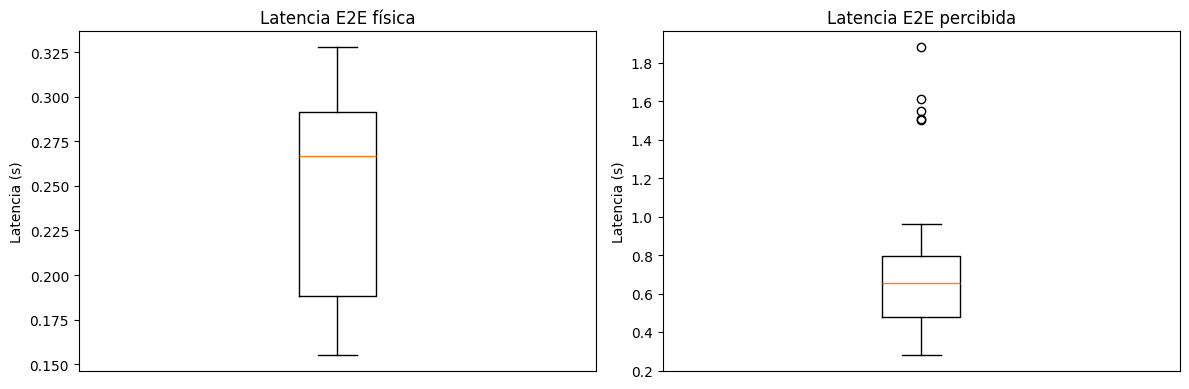

In [26]:
cols = ["L_e2e_odom","L_e2e_amcl"]

labels = {
    "L_e2e_odom": "Latencia E2E física",
    "L_e2e_amcl": "Latencia E2E percibida"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    ax.boxplot(df_events[col].dropna())
    ax.set_title(labels[col])
    ax.set_ylabel("Latencia (s)")
    ax.set_xticks([])
    
plt.tight_layout()
plt.show()


## 8.3. Latencia por goal

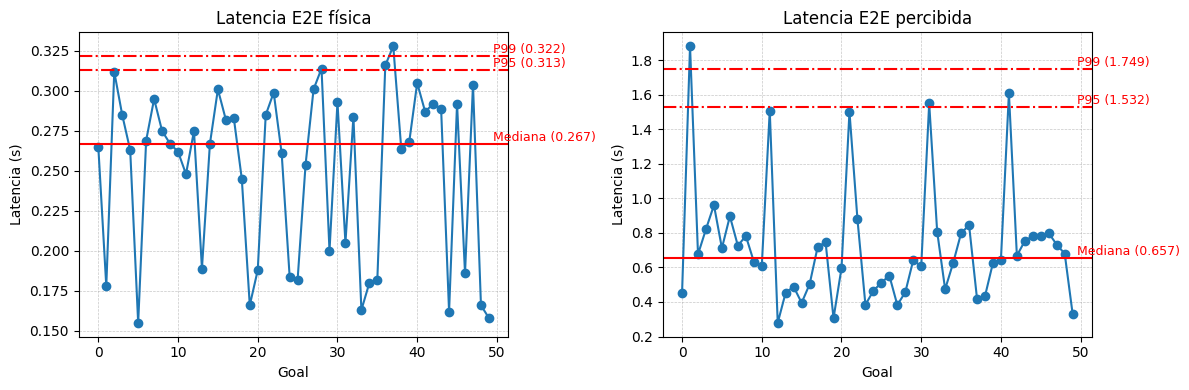

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cols = ["L_e2e_odom", "L_e2e_amcl"]
titles = ["Latencia E2E física", "Latencia E2E percibida"]

for ax, col, title in zip(axes, cols, titles):
    
    x = df_events["goal_id"]
    y = df_events[col]

    # métricas
    median = y.median()
    p95 = y.quantile(0.95)
    p99 = y.quantile(0.99)

    ax.plot(x, y, marker='o')

    # función local para cada subplot
    def hline(ax, y_val, text, style):
        ax.axhline(y_val, color='red', linestyle=style)
        ax.text(
            x.max(), y_val,
            f" {text} ({y_val:.3f})",
            color='red',
            fontsize=9,
            verticalalignment='bottom'
        )

    # líneas
    hline(ax, median, "Mediana", '-')
    hline(ax, p95, "P95", '-.')
    hline(ax, p99, "P99", '-.')

    ax.set_xlabel("Goal")
    ax.set_ylabel("Latencia (s)")
    ax.set_title(title)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


plt.tight_layout()

# --- Guardado con transparencia ---
plt.savefig("../../docs/figures/e2e_latency_per_goal.png",
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

## 8.4. CDF

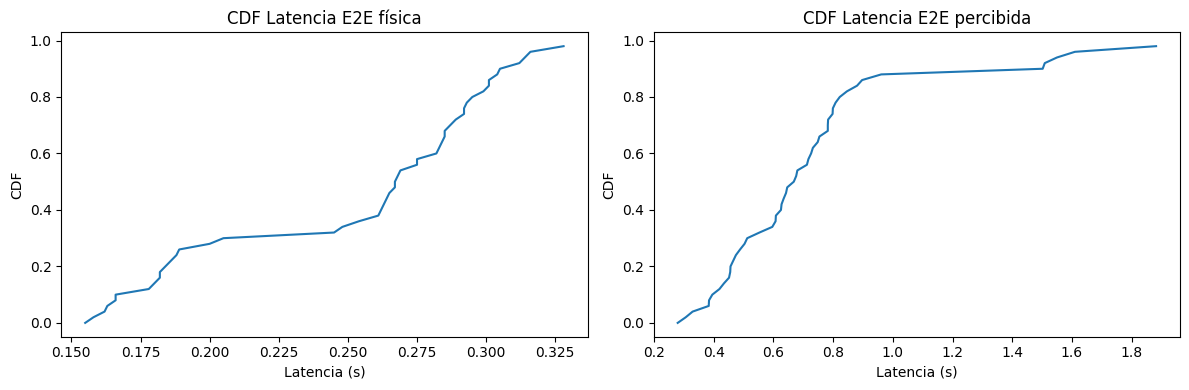

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cols = ["L_e2e_odom", "L_e2e_amcl"]
titles = ["CDF Latencia E2E física", "CDF Latencia E2E percibida"]


for ax, col, title in zip(axes, cols, titles):
    
    sorted_lat = np.sort(df_events[col])
    cdf = np.arange(len(sorted_lat)) / len(sorted_lat)

    ax.plot(sorted_lat, cdf)
    ax.set_xlabel("Latencia (s)")
    ax.set_ylabel("CDF")
    ax.set_title(title)

plt.tight_layout()
plt.show()

## Grafica de barras apiladas normalizadas (100%)

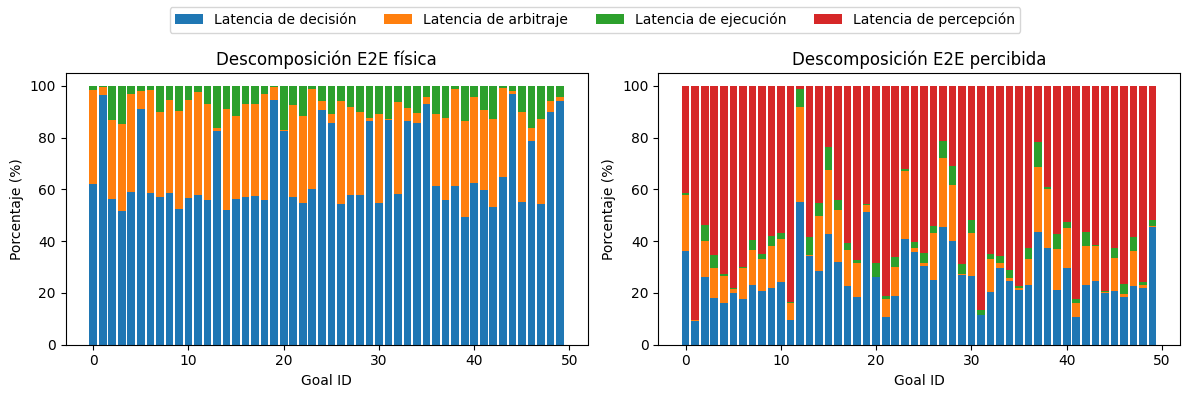

In [29]:
cols_physical = ["L_plan_control", "L_mux", "L_exec"]
cols_perceived = ["L_plan_control", "L_mux", "L_exec", "L_local"]

labels = {
    "L_plan_control": "Latencia de decisión",
    "L_mux": "Latencia de arbitraje",
    "L_exec": "Latencia de ejecución",
    "L_local": "Latencia de percepción"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -------------------------
# E2E FÍSICA (ODOM)
# -------------------------
df_plot = df_events.copy()
df_plot = df_plot[df_plot["L_e2e_odom"] > 0]

for col in cols_physical:
    df_plot[col] = df_plot[col] / df_plot["L_e2e_odom"] * 100

bottom = None

for col in cols_physical:
    axes[0].bar(
        df_plot["goal_id"],
        df_plot[col],
        bottom=bottom,
        label=labels[col]
    )
    if bottom is None:
        bottom = df_plot[col].values
    else:
        bottom = bottom + df_plot[col].values

axes[0].set_title("Descomposición E2E física")
axes[0].set_xlabel("Goal ID")
axes[0].set_ylabel("Porcentaje (%)")


# -------------------------
# E2E PERCIBIDA (AMCL)
# -------------------------
df_plot = df_events.copy()
df_plot = df_plot[df_plot["L_e2e_amcl"] > 0]

for col in cols_perceived:
    df_plot[col] = df_plot[col] / df_plot["L_e2e_amcl"] * 100

bottom = None

for col in cols_perceived:
    axes[1].bar(
        df_plot["goal_id"],
        df_plot[col],
        bottom=bottom,
        label=labels[col]
    )
    if bottom is None:
        bottom = df_plot[col].values
    else:
        bottom = bottom + df_plot[col].values

axes[1].set_title("Descomposición E2E percibida")
axes[1].set_xlabel("Goal ID")
axes[1].set_ylabel("Porcentaje (%)")


# Leyenda común
handles, lbls = axes[1].get_legend_handles_labels()
fig.legend(handles, lbls, loc="upper center", ncol=4)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("../../docs/figures/e2e_latency_decomposition.png",
            dpi=300,
            transparent=True,
            bbox_inches='tight')

plt.show()

# 9. Analisis del jitter

## 9.1 Metricas de jitter

In [30]:
cols = ["L_e2e_odom", "L_e2e_amcl"]

jitter_stats = {}

for col in cols:
    y = df_events[col].sort_index()

    jitter = y.diff().abs().dropna()

    jitter_stats[col] = {
        "mean": y.mean(),
        "std": y.std(),
        "cv": y.std() / y.mean(),
        "jitter_mean": jitter.mean(),
        "jitter_p95": jitter.quantile(0.95),
        "jitter_p99": jitter.quantile(0.99),
    }

jitter_df = pd.DataFrame(jitter_stats).T
print(jitter_df)

               mean       std        cv  jitter_mean  jitter_p95  jitter_p99
L_e2e_odom  0.24948  0.053093  0.212813     0.055653      0.1324     0.13608
L_e2e_amcl  0.71790  0.345731  0.481587     0.316041      1.1092     1.33452


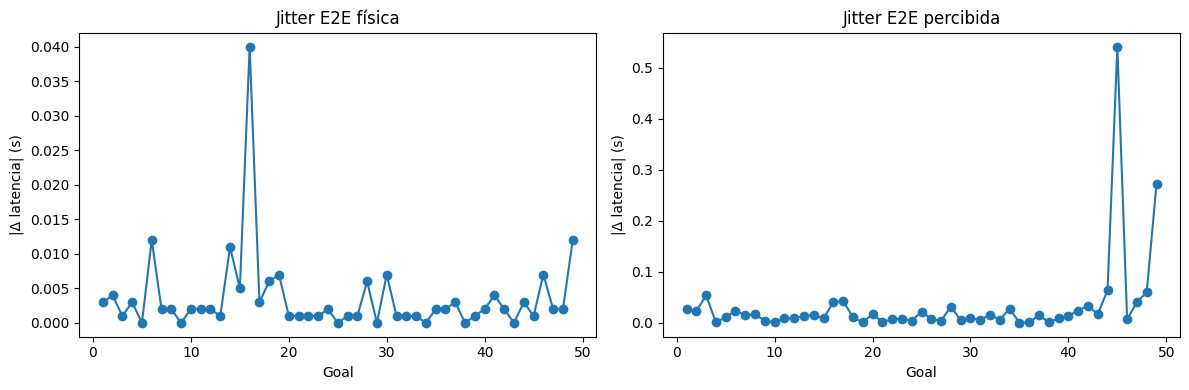

In [31]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cols = ["L_e2e_odom", "L_e2e_amcl"]
titles = ["Jitter E2E física", "Jitter E2E percibida"]

for ax, col, title in zip(axes, cols, titles):
    
    y = df_events[col].sort_values().reset_index(drop=True)
    jitter = y.diff().abs()

    ax.plot(jitter, marker='o')
    ax.set_title(title)
    ax.set_xlabel("Goal")
    ax.set_ylabel("|Δ latencia| (s)")

plt.tight_layout()
plt.show()

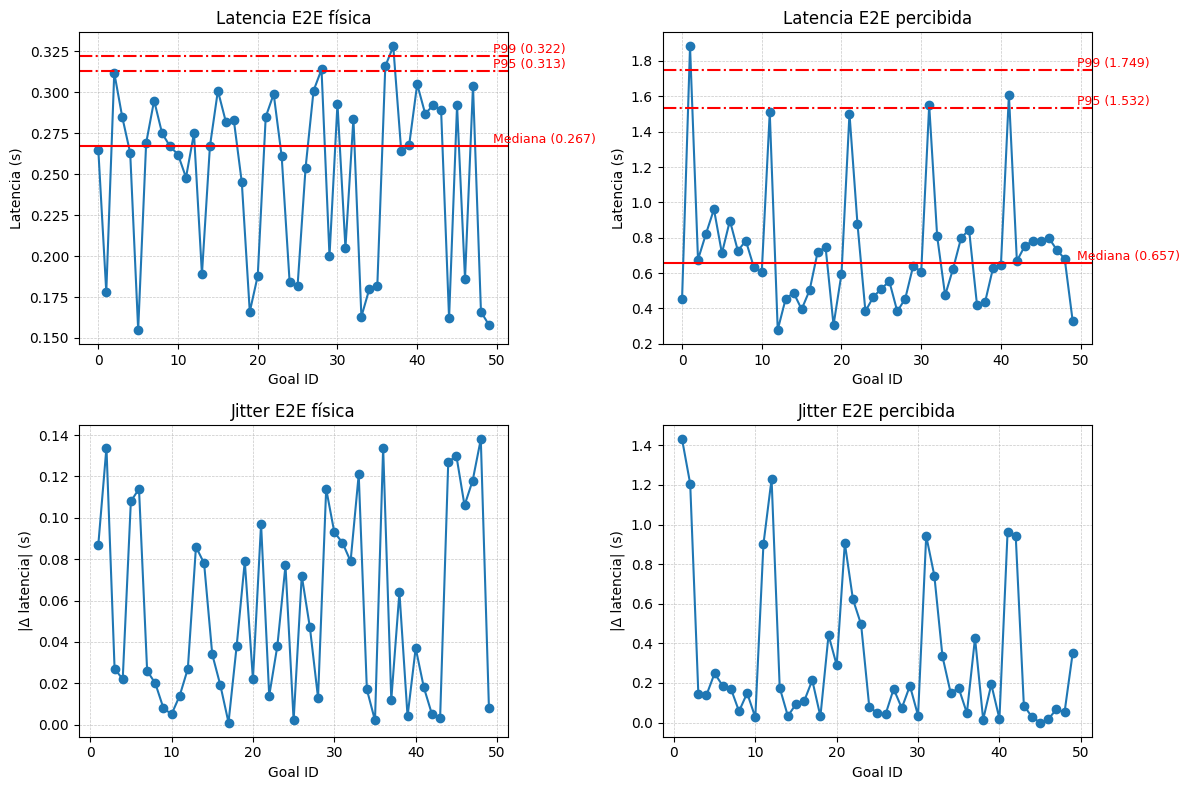

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

cols = ["L_e2e_odom", "L_e2e_amcl"]

titles_latency = ["Latencia E2E física", "Latencia E2E percibida"]
titles_jitter = ["Jitter E2E física", "Jitter E2E percibida"]

# =========================
# FILA 1 → LATENCIA
# =========================
for i, (col, title) in enumerate(zip(cols, titles_latency)):
    
    ax = axes[0, i]

    x = df_events["goal_id"]
    y = df_events[col]

    # métricas
    median = y.median()
    p95 = y.quantile(0.95)
    p99 = y.quantile(0.99)

    ax.plot(x, y, marker='o')

    def hline(ax, y_val, text, style):
        ax.axhline(y_val, color='red', linestyle=style)
        ax.text(
            x.max(), y_val,
            f" {text} ({y_val:.3f})",
            color='red',
            fontsize=9,
            verticalalignment='bottom'
        )

    hline(ax, median, "Mediana", '-')
    hline(ax, p95, "P95", '-.')
    hline(ax, p99, "P99", '-.')

    ax.set_title(title)
    ax.set_xlabel("Goal ID")
    ax.set_ylabel("Latencia (s)")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


# =========================
# FILA 2 → JITTER
# =========================
for i, (col, title) in enumerate(zip(cols, titles_jitter)):
    
    ax = axes[1, i]

    # IMPORTANTE: mantener orden temporal real (no sort)
    y = df_events.sort_values("goal_id")[col].reset_index(drop=True)
    jitter = y.diff().abs()

    ax.plot(jitter, marker='o')

    ax.set_title(title)
    ax.set_xlabel("Goal ID")
    ax.set_ylabel("|Δ latencia| (s)")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


plt.tight_layout()

# --- Guardado ---
# plt.savefig("../../docs/figures/e2e_latency_and_jitter.png",
#             dpi=300,
#             transparent=True,
#             bbox_inches='tight')

plt.show()